In [35]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from typing import Literal
from random import random
from IPython.display import display, Image

In [36]:
class pydenticMultiAttrDataTypeVal(BaseModel):

    name:str
    game: Literal["cricket","football"]

In [37]:
def startplay(state: pydenticMultiAttrDataTypeVal):

    print("--Initiate Model ---")
    return {"name": f"Hello {state.name}, WelCome to Model. You Choose ", "game": state.game}

def cricket(state: pydenticMultiAttrDataTypeVal):

    print("Execution in Cricket Node")
    return {"name": f"{state.name} Cricket", "game": "cricket"}


def football(state: pydenticMultiAttrDataTypeVal):

    print("Execution in Football Node")
    return {"name": f"{state.name} Football", "game": "football"}

def playDecision(state: pydenticMultiAttrDataTypeVal) -> Literal["cricket","football"]:

    if random() > 0.5:
        return "cricket"
    else:
        return "football"


In [38]:
graph = StateGraph(pydenticMultiAttrDataTypeVal)

graph.add_node("startplay",startplay)
graph.add_node("cricket",cricket)
graph.add_node("football", football)

graph.add_edge(START, "startplay")
graph.add_conditional_edges("startplay",playDecision)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

graph_builder = graph.compile()

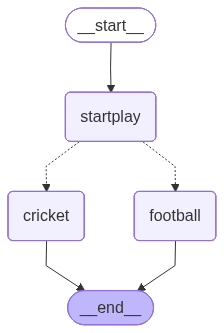

In [39]:
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [68]:
graph_builder.invoke(pydenticMultiAttrDataTypeVal(name="123", game="cricket"))

--Initiate Model ---
Execution in Football Node


{'name': 'Hello 123, WelCome to Model. You Choose  Football',
 'game': 'football'}